In [122]:
# Imports...
import allel
import numpy as np
import zarr
import os
from pathlib import Path
import pandas as pd
import json
from tqdm import tqdm
import pathlib
import glob
import ast
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.stats import chi2
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import statsmodels.api as sm



In [14]:
# VCF to zarr conversion...
X_chrom_vcf = "D:/Genetics_research/genetics_data/VCF_dir/ALL.chrX.phase3_shapeit2_mvncall_integrated_v1c.20130502.genotypes.vcf.gz"
output_zarr_dir = "D:/Genetics_research/genetics_data/ZARR_dir/Outputfile.zarr"
#Conversion logic..

if not Path(output_zarr_dir).exists():
        print("Converting VCF to zarr..." )
        allel.vcf_to_zarr(X_chrom_vcf, output_zarr_file,
                          fields=['calldata/GT', 'variants/POS', 'variants/REF', 'variants/ALT', 'variants/CHROM',
                                  'variants/ID', 'variants/QUAL', 'variants/FILTER_PASS', 'variants/INFO'],
                          overwrite=False)
        print("Conversion complete.")
else:
        print(f"Zarr store already exists at {output_zarr_dir}.")


Zarr store already exists at D:/Genetics_research/genetics_data/ZARR_dir/Outputfile.zarr.


In [36]:
# Loading Study statistics from Pscychiatric Genomicd Consortium..
summary_study_file = "D:/Genetics_research/Public_genomicz_consortium/PGC3_SCZ_wave3.primary.chrX.public.v3.vcf.tsv.gz"
summary_study_df = pd.read_csv(summary_study_file, 
                   sep='\t', 
                   compression='gzip',
                   comment='#')


pd.DataFrame(summary_study_df.columns)

,0
0,CHROM
1,ID
2,POS
3,A1
4,A2
5,FCAS
6,FCON
7,IMPINFO
8,BETA
9,SE


In [4]:
# Summaryb studies dictionary for effective lookup.
# Keep only necessary columns
pgc_clean = summary_study_df[['POS','A1','A2','BETA' ,'ID','FCAS' ,'FCON','NCAS','NCON','PVAL']].copy()

# Uppercase alleles
pgc_clean['A1'] = pgc_clean['A1'].str.upper()
pgc_clean['A2'] = pgc_clean['A2'].str.upper()

# Remove duplicate POS if any (keep first)
pgc_clean = pgc_clean.drop_duplicates(subset='POS')

# Build dictionary
PGC_lookup = pgc_clean.set_index('POS').to_dict(orient='index')


In [5]:
callset = zarr.open(output_zarr_dir,mode = "r")

GT_Field = callset['calldata/GT']   # Genotype data
variants_field = {
        "POS": callset['variants/POS'],
        "REF": callset['variants/REF'],
        "ALT": callset['variants/ALT'],
        "CHROM": callset['variants/CHROM'],
        "ID": callset['variants/ID']
                      } 



In [6]:
# find the "Active Zone" of genomic data efficiently..
def get_active_range(zarr_pos_array, PGC_lookup):
    ref_min = min(PGC_lookup.keys())
    ref_max = max(PGC_lookup.keys())
    
    # Fast binary search for indices
    strt_idx = np.searchsorted(zarr_pos_array, ref_min)
    end_idx = np.searchsorted(zarr_pos_array, ref_max, side='right')
    
    return strt_idx, end_idx

indices = get_active_range(variants_field['POS'][:], PGC_lookup)

strt_idx= indices[0]
end_idx = indices[1]
print(strt_idx)
print(end_idx)


129050
3458222


In [7]:
len(summary_study_df)

3877

In [8]:
# Compliment function..
def complement(allele):
    comp = {"A":"T","T":"A","C":"G","G":"C"}
    return comp.get(allele, allele)


In [9]:

# --- 1. DATA LOADING ---
# Loading data from 1000 Genomes Zarr store
callset = zarr.open(output_zarr_dir,mode = "r")

chrom_label = callset['variants/CHROM'][strt_idx]
GT_Field = callset['calldata/GT']

variants_field = {
    "POS": callset['variants/POS'],
    "REF": callset['variants/REF'],
    "ALT": callset['variants/ALT'],
    "CHROM": callset['variants/CHROM'],
    "ID": callset['variants/ID']
}

# Slicing up loaded data...
variants_position_sliced = variants_field['POS'][strt_idx:end_idx]
variants_ref_sliced = variants_field['REF'][strt_idx:end_idx]
variants_alt_sliced = variants_field['ALT'][strt_idx:end_idx]
variants_chromosome_sliced = variants_field['CHROM'][strt_idx:end_idx]
variants_rsid_sliced = variants_field['ID'][strt_idx:end_idx]

# Define paths
output_variant_mapped_data_path = "D:/Genetics_research/mapped_data/X.json"
output_gt_mapped_data_path = "D:/Genetics_research/mapped_data/gt.npy"

# --- 2. SETUP PARAMETERS ---
chunk_length = 1600
n_variants = len(variants_position_sliced)
mapped_variants = []
mapped_genotype = []
seen_positions = set()

# --- 3. MAIN MAPPING LOOP ---
if os.path.exists(output_variant_mapped_data_path) and os.path.exists(output_gt_mapped_data_path):
    print("--- Data already mapped and exists ---")
else:
    print(f"🚀 Mapping started for Chromosome {chrom_label}...")
    for i in tqdm(range(0, n_variants, chunk_length)):
        local_end = min(i + chunk_length, n_variants)
        b_start = strt_idx + i
        b_end = min(strt_idx + i + chunk_length, end_idx)
        
        # Extract variant metadata
        ref_Position = variants_position_sliced[i:local_end]
        ref_REF = variants_ref_sliced[i:local_end]
        ref_ALT = variants_alt_sliced[i:local_end]
        
        # Extract Genotype data
        gt_chunk = GT_Field[b_start:b_end, :]
        
        for j in range(len(ref_Position)):

            try:
                pos = int(ref_Position[j])
            except:
                continue
        
            # Skip if not in PGC or already mapped
            if pos not in PGC_lookup or pos in seen_positions:
                continue
        
            pgc_entry = PGC_lookup[pos]
            A1 = pgc_entry['A1']
            A2 = pgc_entry['A2']
        
            # Clean alleles
            REF = str(ref_REF[j]).replace("b'", "").replace("'", "").strip().upper()
            ALT_list = [
                str(a).replace("b'", "").replace("'", "").strip().upper()
                for a in ref_ALT[j] if a != ''
            ]
        
            # Skip multi-allelic
            if len(ALT_list) != 1:
                continue
        
            ALT = ALT_list[0]
            flip = None
        
            # ---- Harmonization ----
            if A1 == ALT and A2 == REF:
                flip = False
        
            elif A1 == REF and A2 == ALT:
                flip = True
        
            elif complement(A1) == ALT and complement(A2) == REF:
                flip = False
        
            elif complement(A1) == REF and complement(A2) == ALT:
                flip = True
        
            elif {REF, ALT} in [{"A","T"}, {"C","G"}]:
                continue
        
            else:
                continue

            
            # ---- Passed harmonization ----
            
            seen_positions.add(pos)
            idx = int(strt_idx + i + j)
        
            gv = allel.GenotypeArray([gt_chunk[j]])
            gv_val = gv.values[0]
           
            
            
            valid_mask = (gv_val != -1).all(axis=1)
            dosage = np.sum(np.where(gv_val == -1, 0, gv_val), axis=1)
            dosage[~valid_mask] = -1
            
        
            if flip:
                dosage = np.where(dosage == -1,-1, 2 - dosage)
        
            mapped_genotype.append(dosage.astype(np.int8))
        
            mapped_variants.append({
                'pos': pos,
                'A1': A1,
                'A2': A2,
                'BETA': pgc_entry['BETA'],
                'NCAS': pgc_entry['NCAS'] ,
                'NCON' : pgc_entry['NCON'] ,
                'PVAL': pgc_entry['PVAL'] ,
                'FCAS' : pgc_entry['FCAS'] ,
                'FCON' : pgc_entry['FCON'] ,
                'flip': flip ,
                'ID': pgc_entry['ID']
            })
        
                 
        
    # --- 4. FORCED SAVE BLOCK ---
    if mapped_genotype:
        try:
            print(f"📦 Finalizing {len(mapped_variants)} variants...")
            
            # Save JSON with forced flush
            json_data = json.dumps(mapped_variants, indent=4)
            with open(output_variant_mapped_data_path, "w", encoding="utf-8") as f:
                f.write(json_data)
                f.flush()
                os.fsync(f.fileno())
            
            # Save Genotype Matrix without Transpose i.e standard(variants ,individuals)
            final_matrix = np.vstack(mapped_genotype)
            
            np.save(output_gt_mapped_data_path, final_matrix)
            
            print(f" Success! Matrix saved to: {output_gt_mapped_data_path}")
            print(f" Final ML Shape: {final_matrix_ml.shape} (Samples, Variants)")
            print(f" JSON saved to: {output_variant_mapped_data_path}")
            
        except Exception as e:
            print(f" Save failed: {e}")

    # --- 5. AUDIT ---
    total_mapped = len(mapped_variants)
    valid_pos_set =  len(summary_study_df)
    pct_of_1000G_kept = (total_mapped / n_variants) * 100
    pct_of_PGC_recovered = (total_mapped / valid_pos_set) * 100
    
    print(f"\n--- Global Audit: Chromosome {chrom_label} ---")
    print(f"Total variants in 1000G Slice: {n_variants:,}")
    print(f"Total target SNPs in PGC:      {valid_pos_set:,}")
    print(f"Successfully Mapped variants:   {total_mapped:,}")
    print(f"1000G Retention: {pct_of_1000G_kept:.2f}%")
    print(f"PGC Recovery:    {pct_of_PGC_recovered:.2f}%")

--- Data already mapped and exists ---


# LOADING THE HIGH CONFIDENT MAPPED RAW DATA.. 

In [10]:
# Loading high confidence mapped variant data..
df = pd.read_json(output_variant_mapped_data_path)

# Computing parameters for QC..



# Computing Allele freqencies..
   
df['AF'] = ( (df['FCAS'] * df['NCAS']) + (df['FCON'] * df['NCON']) ) / (df['NCAS'] + df['NCON']) 
df['AF'] = df['AF'].fillna(0)
 
df['MAF'] = np.minimum(df['AF'], 1-df['AF'])
df['mean_dosage'] = 2*df['AF']
df['mean_variance'] = (2*df['AF'])*(1-df['AF'])
   
# Computing Minor allele frequencies..
df['MAF'] = np.minimum(df['AF'], 1 - df['AF']) 
df['mean_dosage'] = (2 * df['AF'])
df['mean_variance'] = ( (2*df['AF']) * (1 - df['AF'] ))



df


,pos,A1,A2,BETA,NCAS,NCON,PVAL,FCAS,FCON,flip,ID,AF,MAF,mean_dosage,mean_variance
0,3738148,G,A,0.120801,64402,85066,0.000518,0.977,0.975,True,rs142951748,0.975862,0.024138,1.951723,0.047111
1,5193109,A,C,-0.072603,64402,85066,0.000776,0.967,0.970,True,rs149932678,0.968707,0.031293,1.937415,0.060627
2,5291808,G,A,-0.089104,64402,85066,0.000385,0.971,0.974,True,rs139504510,0.972707,0.027293,1.945415,0.053095
3,5382326,G,A,0.075599,65636,88156,0.000568,0.972,0.969,True,rs139816491,0.970280,0.029720,1.940561,0.057673
4,5568248,G,A,0.023297,71788,92074,0.000263,0.531,0.519,True,rs5961786,0.524257,0.475743,1.048514,0.498823
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3815,154918383,G,T,0.033502,71788,92074,0.000013,0.732,0.737,True,rs641588,0.734809,0.265191,1.469619,0.389729
3816,154925045,C,T,0.034701,71788,92074,0.000006,0.729,0.734,True,rs509981,0.731809,0.268191,1.463619,0.392529
3817,154927199,C,T,0.036901,71788,92074,0.000652,0.816,0.826,True,rs645904,0.821619,0.178381,1.643238,0.293122
3818,154927581,G,A,0.030500,71788,92074,0.000088,0.660,0.676,True,rs644138,0.668990,0.331010,1.337981,0.442884


In [11]:
""" Taking Pseudo Autosomal regions in consideration..
    these regions are likely to be  
    found within the coordinated
    - PAR1 = 60,001 to 2,699,520
    - PAR2 = 154,931,044 to 155,260,560 """


# hg19 coordinates
PAR1 = df[(df['pos'] >= 60001) & (df['pos'] <= 2699520)].index
PAR2 = df[(df['pos'] >= 154931044) & (df['pos'] <= 155260560)].index

len(PAR1)

0

In [12]:
# Loading high confidence mapped Genotype data..
genotype_matrix = np.load(output_gt_mapped_data_path)
genotype_df = pd.DataFrame(genotype_matrix)


sample_cols = {col: f"Sample_{col}" for col in genotype_df.columns if col != 'variant_id'}
genotype_df = genotype_df.rename(columns=sample_cols)

# Hadling the sentinal value -1 otherwise it'll cause imputations..
genotype_df= genotype_df.replace(-1 ,np.nan)
genotype_df

,Sample_0,Sample_1,Sample_2,Sample_3,Sample_4,Sample_5,Sample_6,Sample_7,Sample_8,Sample_9,...,Sample_2494,Sample_2495,Sample_2496,Sample_2497,Sample_2498,Sample_2499,Sample_2500,Sample_2501,Sample_2502,Sample_2503
0,NaN,2,2,2,NaN,2,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
1,NaN,2,2,1,NaN,2,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
2,NaN,2,2,1,NaN,2,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
3,NaN,2,2,2,NaN,2,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2
4,NaN,0,1,2,NaN,1,NaN,NaN,0,NaN,...,NaN,NaN,NaN,NaN,NaN,2,1,1,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3815,NaN,2,2,1,NaN,2,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,2,1,2,1,1
3816,NaN,2,2,1,NaN,2,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,2,1,2,1,1
3817,NaN,2,2,1,NaN,2,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,2,1,2,1,1
3818,NaN,2,2,1,NaN,2,NaN,NaN,2,NaN,...,NaN,NaN,NaN,NaN,NaN,2,1,2,1,1


# QUALITY CONTROL FILTERING....

In [13]:

# Individual call rate filtering..

individual_call_rate = genotype_df.notna().mean(axis=0)


# Dropping those with < 98% call rate..
bad_individuals = individual_call_rate[individual_call_rate < 0.90].index
genotype_df_filtered = genotype_df.drop(columns=bad_individuals)


# Check the new shape to see how many samples survived
print("Individual level call rate...")
print(f"Original shape before: {genotype_df.shape}")
print(f"Filtered shape after : {genotype_df_filtered.shape}")



# Variant level call rate ; 
variant_call_rate = genotype_df.notna().mean(axis=1)

# Dropping those with < 98% call rate..
bad_snp_individuals = individual_call_rate[individual_call_rate < 0.98].index
genotype_df_snp_filtered = genotype_df.drop(bad_snp_individuals)


# Check the new shape to see how many samples survived
print("\nvariant level call rate...")
print(f"Original shape Before SNP filter: {genotype_df_filtered.shape}")
print(f"Filtered shape After SNP filter: {genotype_df_snp_filtered.shape}")

Individual level call rate...
Original shape before: (3820, 2504)
Filtered shape after : (3820, 1271)


KeyError: "['Sample_0', 'Sample_4', 'Sample_6', 'Sample_7', 'Sample_9', 'Sample_10', 'Sample_11', 'Sample_14', 'Sample_15', 'Sample_16', 'Sample_17', 'Sample_18', 'Sample_19', 'Sample_21', 'Sample_27', 'Sample_30', 'Sample_32', 'Sample_35', 'Sample_37', 'Sample_38', 'Sample_39', 'Sample_40', 'Sample_41', 'Sample_42', 'Sample_43', 'Sample_45', 'Sample_46', 'Sample_48', 'Sample_50', 'Sample_51', 'Sample_53', 'Sample_54', 'Sample_63', 'Sample_64', 'Sample_65', 'Sample_66', 'Sample_67', 'Sample_68', 'Sample_69', 'Sample_70', 'Sample_71', 'Sample_75', 'Sample_82', 'Sample_83', 'Sample_84', 'Sample_86', 'Sample_88', 'Sample_89', 'Sample_93', 'Sample_97', 'Sample_101', 'Sample_102', 'Sample_104', 'Sample_107', 'Sample_109', 'Sample_113', 'Sample_114', 'Sample_115', 'Sample_118', 'Sample_121', 'Sample_124', 'Sample_126', 'Sample_127', 'Sample_133', 'Sample_136', 'Sample_140', 'Sample_145', 'Sample_146', 'Sample_148', 'Sample_150', 'Sample_151', 'Sample_154', 'Sample_158', 'Sample_163', 'Sample

In [15]:
# Cleaning the variant metadata...

MAF_filtered_df = df[df['MAF'] >= 0.05]

# Cleaning corrosponding Genotype data..
bad_variants = df[df['MAF'] <= 0.05].index
genotype_df_MAF_filtered = genotype_df.drop( bad_variants)



# Check the new shape to see how many samples survived
print(f"Original shape: {df.shape}")
print(f"Filtered shape: {MAF_filtered_df.shape}")



Original shape: (3820, 15)
Filtered shape: (3739, 15)


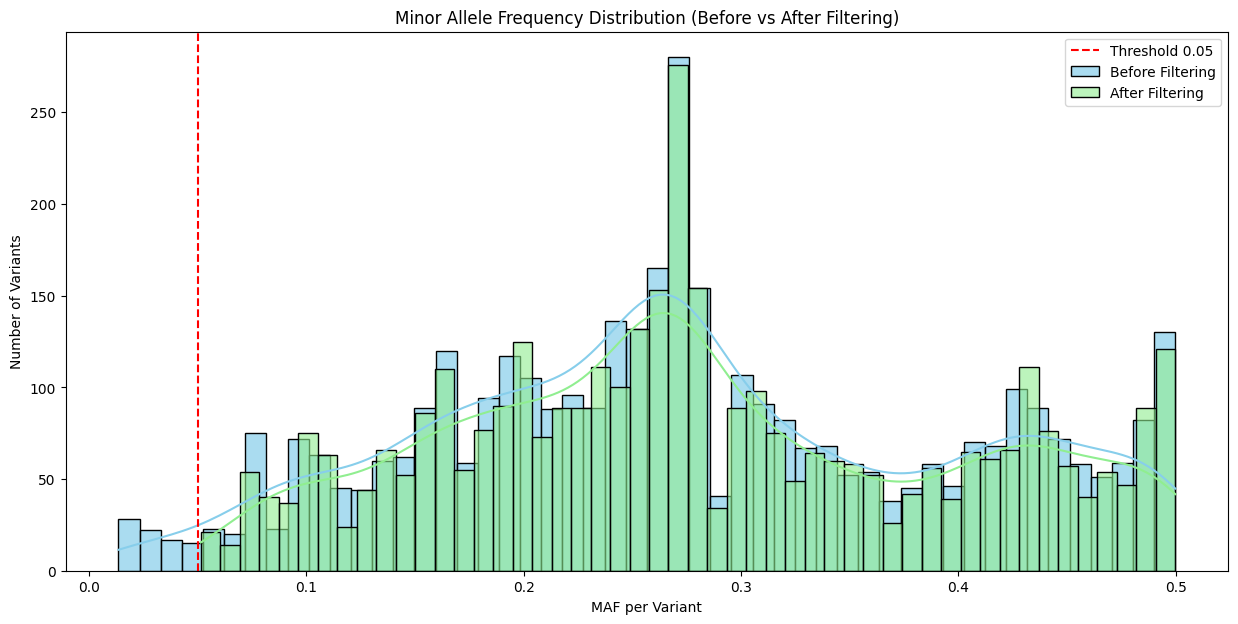

In [16]:
plt.figure(figsize=(15,7))
sns.histplot(df['MAF'], bins=50, kde=True, color="skyblue", label="Before Filtering", alpha=0.7)
sns.histplot(MAF_filtered_df['MAF'], bins=50, kde=True, color="lightgreen", label="After Filtering", alpha=0.6)
plt.axvline(0.05, color="red", linestyle="--", label="Threshold 0.05")
plt.title("Minor Allele Frequency Distribution (Before vs After Filtering)")
plt.xlabel("MAF per Variant")
plt.ylabel("Number of Variants")
plt.legend()
plt.show()

In [ ]:
x_genotype.shape

# Heterozygosity...

In [17]:
# NOTE ; it's per individual heterozygous call rate
    
x_genotype = genotype_df_MAF_filtered.iloc[:,1: ].T



# Heterozygous counts..
het_count = (x_genotype == 1).sum(axis =1)
# Total non missing calls..
total_count =x_genotype.notna().sum(axis =1)

#Rate..
het_rate = het_count/total_count

# Add as a new row in a metadata dataframe (not inside genotype_df, since rows = variants)
het_rate_df = pd.DataFrame({'het_rate': het_rate})


In [18]:
het_rate_df

,het_rate
Sample_1,0.295801
Sample_2,0.383792
Sample_3,0.465900
Sample_4,NaN
Sample_5,0.374164
...,...
Sample_2499,0.295534
Sample_2500,0.420701
Sample_2501,0.259695
Sample_2502,0.405991


# Inferring Genetic sex..

In [19]:
""" Sex check on X chromosome..
and Inferring sex by X chromosome heteroxzygosity by the logic ;
     -het_Rate < 0.05 likely male  
     -het_Rate > 0.15 likely female ,"""

# Inferring sex..

sex_inferred = np.where(het_rate < 0.22, 'male', 'Female')


sample_info = pd.DataFrame({
    "het_rate": het_rate, 
    "sex_inferred": sex_inferred }, index=x_genotype.index)


    
sample_info['sex_inferred'] = sex_inferred
print(sample_info['sex_inferred'].value_counts())

sex_inferred
Female    2399
male       104
Name: count, dtype: int64


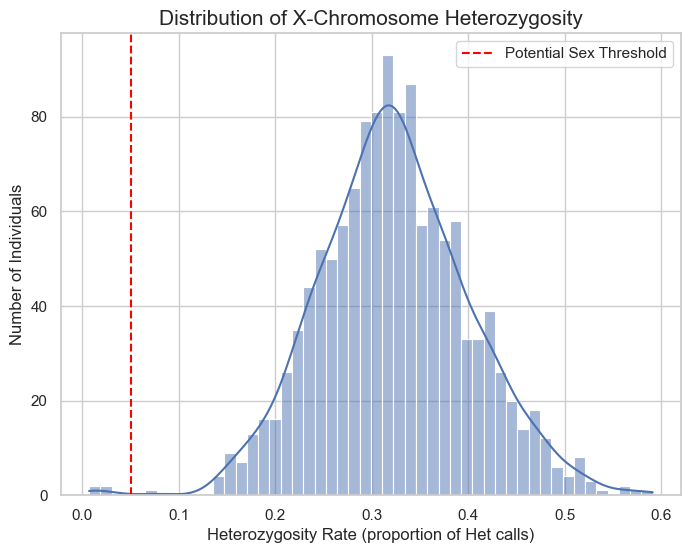

In [20]:

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 6))

# Plot the heterozygousity distribution
sns.histplot(het_rate_df, bins=50, kde=True, color='skyblue')

plt.title('Distribution of X-Chromosome Heterozygosity', fontsize=15)
plt.xlabel('Heterozygosity Rate (proportion of Het calls)', fontsize=12)
plt.ylabel('Number of Individuals', fontsize=12)

# Optional: Add a vertical line at 0.05 to see the potential Male/Female split
plt.axvline(x=0.05, color='red', linestyle='--', label='Potential Sex Threshold')
plt.legend()

plt.show()


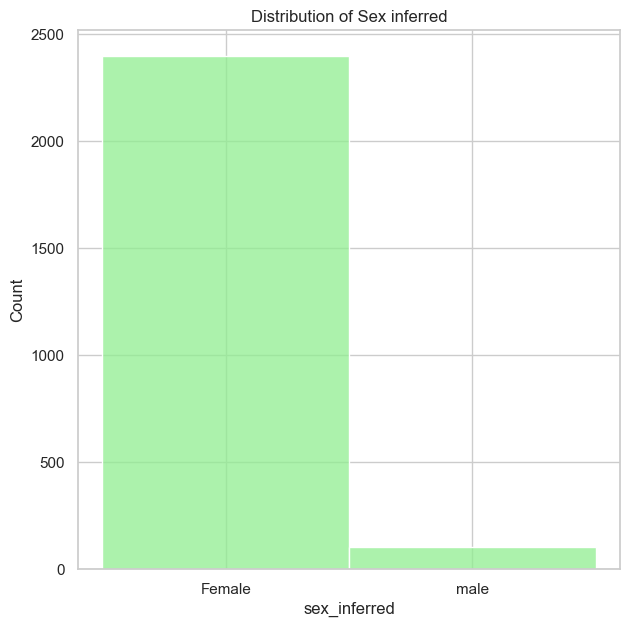

In [21]:
plt.figure(figsize=(7,7)) 
sns.histplot(sample_info['sex_inferred'], bins=10, color="lightgreen")
plt.title("Distribution of Sex inferred") 
plt.show()

In [22]:
len(sample_info[sample_info['sex_inferred'] == 'Female'])


2399

# Dropping those 'Ambigous' sex inferred samples for Original datasets to avoid downstream data analysis noice...

In [23]:
# Identify ambiguous individuals
Ambigious_samples = sample_info[sample_info['sex_inferred'] == 'Ambigious'].index

# Drop those individuals from genotype and sample_info and variant metadata too..
genotype_df_sex_filtered = genotype_df_MAF_filtered.T.drop(Ambigious_samples)
sample_info_filtered = sample_info.drop(index=Ambigious_samples)
SEX_filtered_df = MAF_filtered_df.drop(Ambigious_samples)

print(genotype_df_sex_filtered.shape)
print(SEX_filtered_df.shape)


(2504, 3739)
(3739, 15)


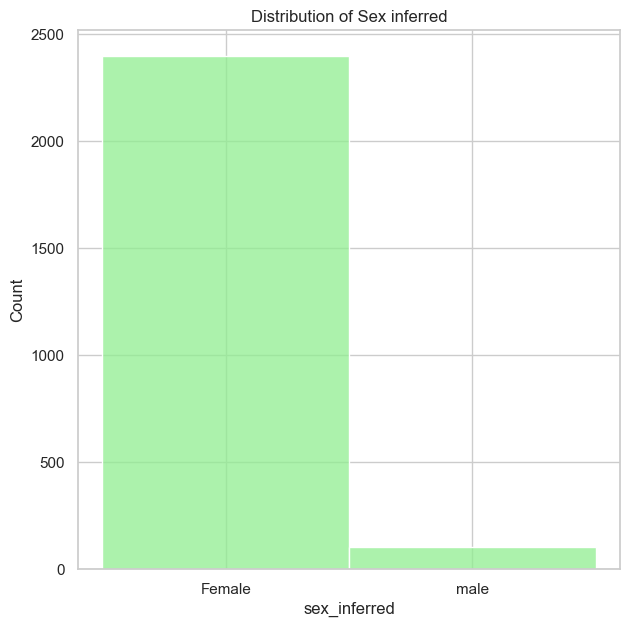

In [25]:
plt.figure(figsize=(7,7)) 
sns.histplot(sample_info_filtered['sex_inferred'], bins=10, color="lightgreen")
plt.title("Distribution of Sex inferred") 
plt.show()

In [27]:
# 1. Isolate Females based on inferred sex


female_samples = sample_info_filtered[sample_info_filtered['sex_inferred'] == 'Female'].index
# subset_females is now (Female_Samples x Variants)
subset_females = genotype_df_sex_filtered.loc[female_samples]

# 2. Run the HWE function on ONLY females
def compute_hwe_final(row):
    counts = row.value_counts()
    n2 = counts.get(2, 0) # HomRef
    n1 = counts.get(1, 0) # Het
    n0 = counts.get(0, 0) # HomAlt
    n = n2 + n1 + n0
    
    if n < 20: return np.nan # Skip SNPs with very low female coverage

    p = (2*n2 + n1) / (2*n)
    q = 1 - p
    if p == 0 or p == 1: return 1.0
    
    exp = np.array([(p**2)*n, (2*p*q)*n, (q**2)*n])
    obs = np.array([n2, n1, n0])
    
    # Chi-square with 1 degree of freedom
    stat = np.sum((obs - exp)**2 / exp)
    return chi2.sf(stat, df=1)

# 3. Calculate and Filter

# 2. Run HWE function on columns (axis=0)
# This gives you one p-value per Variant
hwe_pvals = subset_females.apply(compute_hwe_final, axis=0)

# 3. Identify Variant IDs (Columns) that failed
failed_hwe_snps = hwe_pvals[hwe_pvals < 1e-6].index

# 4. Filter the main DataFrames
# Since variants are COLUMNS in genotype_df, we drop from axis=1
genotype_df_HWE_filtered = genotype_df_sex_filtered.drop(columns=failed_hwe_snps)

# Since variants are likely ROWS in your metadata (SEX_filtered_df), 
# we drop from the index there.
HWE_filtered_df = SEX_filtered_df.drop(index=failed_hwe_snps)

print(f"Variants remaining: {genotype_df_HWE_filtered.shape[1]}")

Variants remaining: 2742


In [31]:
genotype_df_HWE_filtered

,4,5,6,7,8,9,10,11,12,13,...,3806,3807,3809,3810,3811,3813,3815,3816,3817,3819
Sample_0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sample_1,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Sample_2,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Sample_3,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0
Sample_4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Sample_2499,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Sample_2500,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0
Sample_2501,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0
Sample_2502,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,2.0,...,1.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0


In [32]:
print(HWE_filtered_df.shape)
print(genotype_df_HWE_filtered.shape)


(2742, 15)
(2504, 2742)


# Implementing PCA to outshines Ancestory..

In [33]:
scaler = StandardScaler() 


X = genotype_df_HWE_filtered.fillna(genotype_df_HWE_filtered.mean())
X_Scaled = scaler.fit_transform(X)


# PCA...
pca = PCA(n_components = 10)
PCS=  pca.fit_transform(X_Scaled)

pcs_df =pd.DataFrame(
    PCS,
    index = X.index,
    columns = [f'PC{i+1}' for i in range(10)])

# Print explained variance to see how much info each PC holds
print("Explained variance ratio:", pca.explained_variance_ratio_)
pcs_df

Explained variance ratio: [0.09565902 0.08482438 0.05418177 0.04454069 0.03904784 0.03326151
 0.02995413 0.02615924 0.02263169 0.019003  ]


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
Sample_0,-1.529867e-14,-1.649816e-14,2.669021e-15,8.339749e-15,-2.297968e-15,-1.886794e-14,1.213570e-14,1.872295e-14,-3.336571e-15,6.441972e-16
Sample_1,-3.950361e+01,-2.269203e+00,1.348249e+01,6.026732e-01,-9.131053e+00,3.320548e-01,1.353411e+01,9.897547e+00,-8.400273e+00,2.701496e+00
Sample_2,-2.911271e+01,-6.964521e+00,-4.277654e+00,-2.379758e+01,1.277759e+01,-1.448233e+01,-1.055641e+01,1.844181e+01,-7.270653e+00,1.698857e+01
Sample_3,-3.008634e+01,4.025960e+01,-2.125370e+01,2.021084e+01,2.283564e+00,2.268173e+01,6.104616e+00,1.469259e+01,2.558417e+01,-9.322518e-01
Sample_4,2.801656e-17,-6.573693e-17,-2.876688e-16,1.504990e-16,1.067115e-15,-5.348713e-15,1.274907e-14,-7.187159e-15,-2.414175e-14,9.007709e-15
...,...,...,...,...,...,...,...,...,...,...
Sample_2499,-3.920012e-01,-2.493359e+01,-1.091015e+01,1.346177e+01,5.935130e+00,6.822593e+00,1.519028e+00,-8.574241e+00,6.429444e+00,6.324130e+00
Sample_2500,1.151778e+01,-4.649565e+00,-5.214489e+00,8.610153e+00,2.072353e+01,1.880390e+01,1.450823e+01,-6.205946e+00,1.105766e+01,4.841147e+00
Sample_2501,-5.279779e+00,-2.789093e+01,-9.936998e+00,1.046534e+01,1.205105e+01,1.425919e+01,-1.868224e+01,-1.516822e+01,-2.278007e+01,4.159983e+00
Sample_2502,1.649644e+01,4.902351e+00,-2.203807e+01,1.422210e+01,1.572766e+01,3.336342e+00,-1.021267e+01,-3.449865e+00,2.174809e+01,-6.809408e+00


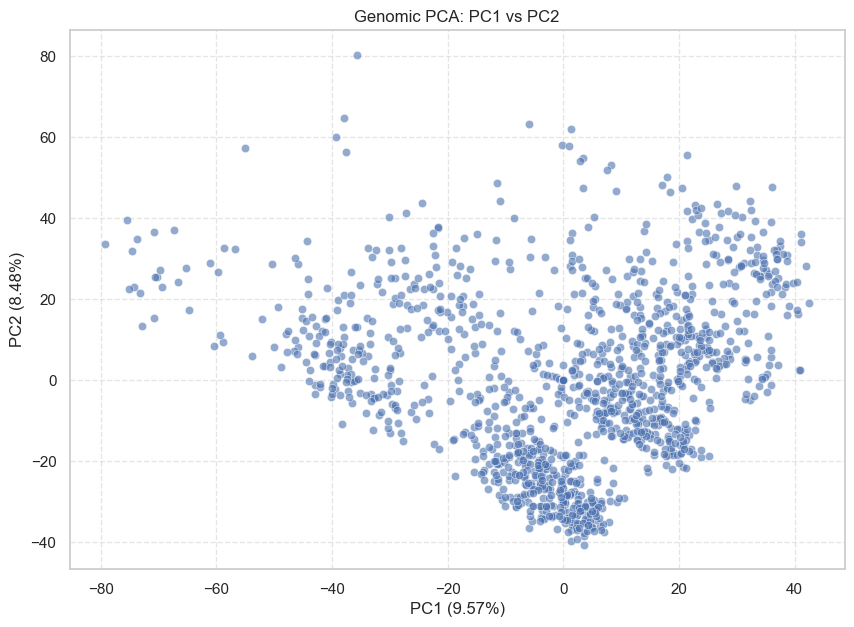

In [34]:

plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', data=pcs_df, alpha=0.6)

plt.title('Genomic PCA: PC1 vs PC2')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Clustering to see any Ancestory...

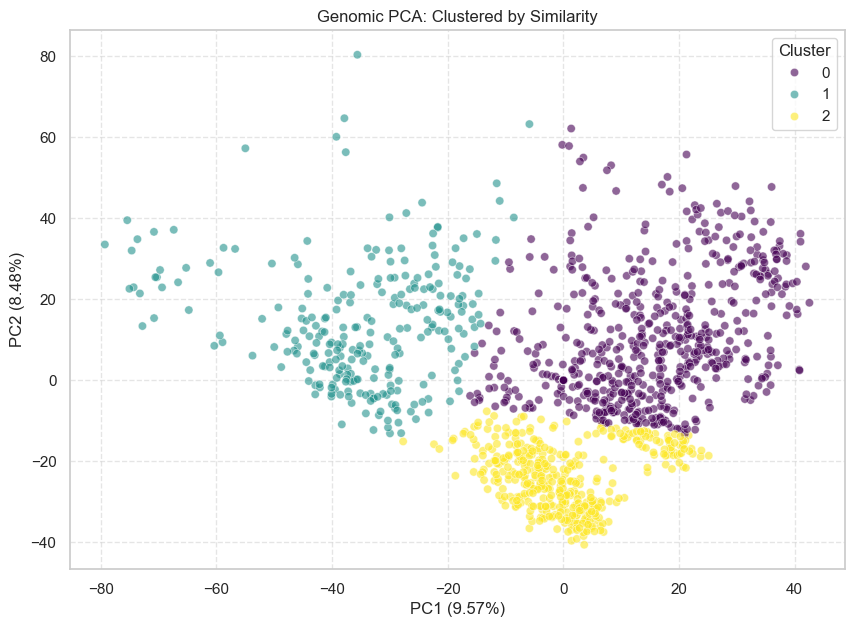

In [35]:
# 1. Discover clusters (adjust n_clusters based on how many you see)
kmeans = KMeans(n_clusters=3, random_state=42)
pcs_df['Cluster'] = kmeans.fit_predict(pcs_df[['PC1', 'PC2']])

# 2. Plot with Seaborn using the new 'Cluster' column
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pcs_df, 
                alpha=0.6, palette='viridis')

plt.title('Genomic PCA: Clustered by Similarity')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


# Manhatten plot..

In [59]:
manhatten_df = HWE_filtered_df.copy()
manhatten_df = manhatten_df.sort_values("pos")
manhatten_df['logp'] = -np.log10(manhatten_df['PVAL'])
manhatten_df

,pos,A1,A2,BETA,NCAS,NCON,PVAL,FCAS,FCON,flip,ID,AF,MAF,mean_dosage,mean_variance,logp
4,5568248,G,A,0.023297,71788,92074,0.000263,0.531,0.519,True,rs5961786,0.524257,0.475743,1.048514,0.498823,3.580209
5,5572299,C,T,0.023199,71788,92074,0.000276,0.529,0.518,True,rs5915584,0.522819,0.477181,1.045638,0.498959,3.558934
6,5574132,C,T,0.023502,71788,92074,0.000238,0.524,0.516,True,rs5916185,0.519505,0.480495,1.039010,0.499239,3.623788
7,5576967,T,C,0.021898,71788,92074,0.000600,0.505,0.489,True,rs11094781,0.496010,0.496010,0.992019,0.499968,3.221849
8,5576988,C,T,0.021801,71788,92074,0.000626,0.506,0.489,True,rs11094782,0.496448,0.496448,0.992895,0.499975,3.203079
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3813,154918242,C,T,0.041996,71788,92074,0.000126,0.878,0.869,True,rs73562846,0.872943,0.127057,1.745886,0.221827,3.898597
3815,154918383,G,T,0.033502,71788,92074,0.000013,0.732,0.737,True,rs641588,0.734809,0.265191,1.469619,0.389729,4.876802
3816,154925045,C,T,0.034701,71788,92074,0.000006,0.729,0.734,True,rs509981,0.731809,0.268191,1.463619,0.392529,5.198802
3817,154927199,C,T,0.036901,71788,92074,0.000652,0.816,0.826,True,rs645904,0.821619,0.178381,1.643238,0.293122,3.185419


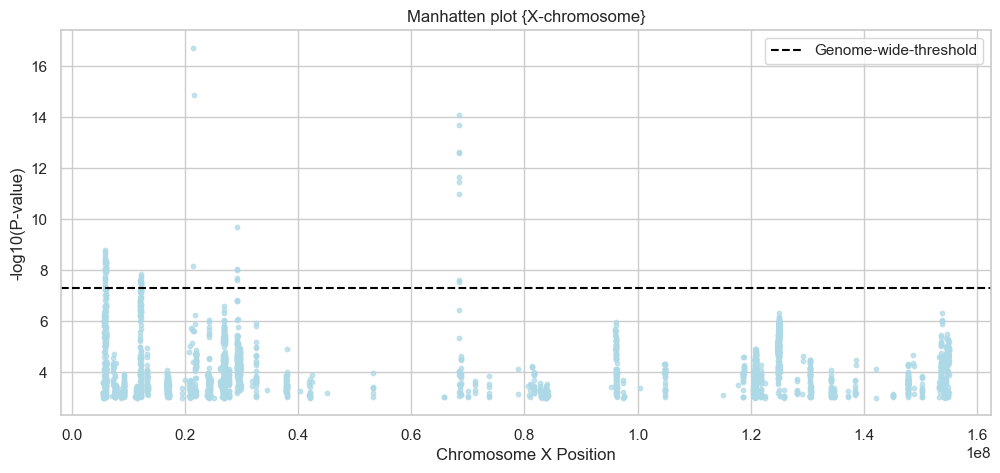

In [60]:
plt.figure(figsize = (12,5))

plt.scatter(
    manhatten_df["pos"],
        manhatten_df['logp'],
    s =10,
    color="lightblue",
    alpha =0.7)
plt.axhline(-np.log10(5e-8) ,color = "black",
                 linestyle="--" ,label ="Genome-wide-threshold")
plt.xlabel("Chromosome X Position")
plt.ylabel("-log10(P-value)")
plt.title("Manhatten plot {X-chromosome}")
plt.legend()
plt.show()

# QQ plot..

In [62]:
pvals = manhatten_df['PVAL'].sort_values()
observed = -np.log10(pvals)

expected = -np.log10(
    np.linspace(1/len(pvals), 1,len(pvals))
)


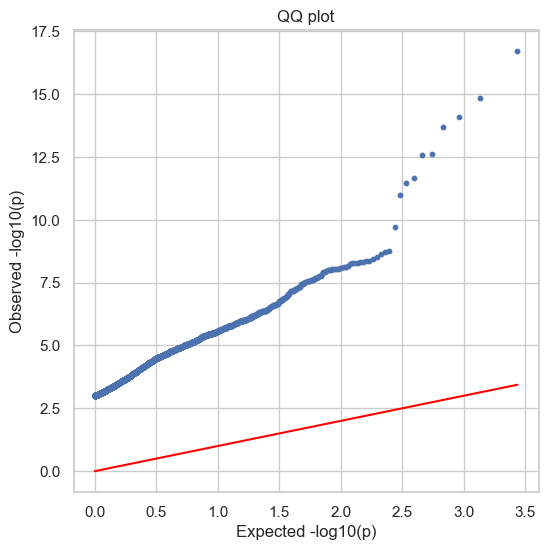

In [65]:
plt.figure(figsize = (6,6))

plt.scatter(expected,observed, s=10)

plt.plot(
    [0,max(expected)], 
    [0,max(expected)] ,
    color="red"
)

plt.xlabel("Expected -log10(p)")
plt.ylabel("Observed -log10(p)")
plt.title("QQ plot")

plt.show()

In [83]:
print(f" Genotype data : {genotype_df_HWE_filtered.shape}")
print(f" Variant data : {HWE_filtered_df.shape}")



 Genotype data : (2504, 2742)
 Variant data : (2742, 15)


In [87]:
betas

array([0.02329652, 0.02319881, 0.02350166, ..., 0.0347009 , 0.03690072,
       0.0343048 ], shape=(2742,))

In [89]:

genotypes_only = genotype_df_HWE_filtered
betas = HWE_filtered_df['BETA'].values

""" Calculate RAW PRS per Variant/Sample
   This multiplies (2504, 2742) by (2742,) to get (2504,)"""

total_sample_prs = genotypes_only.values @ betas

# 4. Standardize
total_sample_prs_z = (total_sample_prs - np.nanmean(total_sample_prs)) / np.nanstd(total_sample_prs)

In [90]:
print(f"Any NaNs? {np.isnan(total_sample_prs_z).any()}")
print(f"Any Infs? {np.isinf(total_sample_prs_z).any()}")
# If True, you may need to use np.nansum() or fill missing values in your genotype data.


Any NaNs? True
Any Infs? False


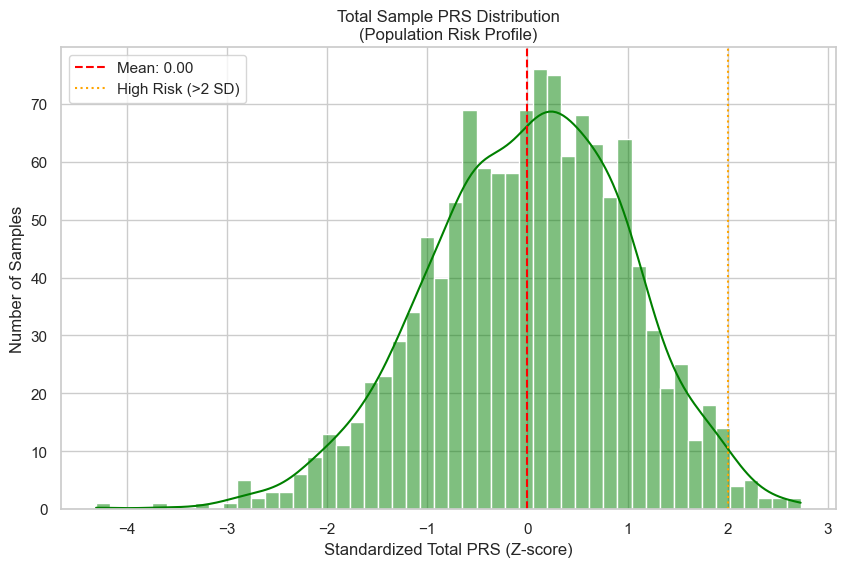

In [94]:

# 1. Clean the data (remove NaNs for plotting)
clean_prs = total_sample_prs_z[~np.isnan(total_sample_prs_z)]

# 2. Create the plot
plt.figure(figsize=(10, 6))
ax3 = sns.histplot(clean_prs, bins=50, color='green', kde=True)

# 3. Add statistical reference lines
plt.axvline(np.mean(clean_prs), color='red', linestyle='--', label=f'Mean: {np.mean(clean_prs):.2f}')
plt.axvline(np.mean(clean_prs) + 2*np.std(clean_prs), color='orange', linestyle=':', label='High Risk (>2 SD)')

plt.title("Total Sample PRS Distribution\n(Population Risk Profile)")
plt.xlabel("Standardized Total PRS (Z-score)")
plt.ylabel("Number of Samples")
plt.legend()
plt.show()

# Ancestory v/s PRS..

In [119]:
PRS_df =pd.DataFrame( {
     "PRS" : total_sample_prs_z
})
pcs_df_reset = pcs_df.reset_index(drop=True)
# Adding principle components to the  PRS data
PRS_df["PC1"] = pcs_df_reset['PC1']
PRS_df["PC2"] = pcs_df_reset['PC2']
PRS_df["PC3"] = pcs_df_reset['PC3']

#  Renoving NANS..
PRS_df = PRS_df.dropna()
PRS_df

,PRS,PC1,PC2,PC3
1,-1.074489,-39.503613,-2.269203,13.482492
2,-0.901487,-29.112710,-6.964521,-4.277654
3,-0.353068,-30.086343,40.259600,-21.253696
5,-2.022711,-47.925645,11.433540,5.417171
8,1.941689,-13.110631,-26.906446,-5.740692
...,...,...,...,...
2499,1.969271,-0.392001,-24.933586,-10.910153
2500,0.849363,11.517783,-4.649565,-5.214489
2501,1.773355,-5.279779,-27.890934,-9.936998
2502,0.232783,16.496443,4.902351,-22.038075


In [126]:
# Regresion...
X=  PRS_df[["PC1" ,"PC2","PC3"]]
X = sm.add_constant(X)

y = PRS_df['PRS']
model = sm.OLS(y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                    PRS   R-squared:                       0.529
Model:                            OLS   Adj. R-squared:                  0.528
Method:                 Least Squares   F-statistic:                     474.2
Date:                Tue, 10 Mar 2026   Prob (F-statistic):          1.64e-206
Time:                        02:58:03   Log-Likelihood:                -1325.1
No. Observations:                1271   AIC:                             2658.
Df Residuals:                    1267   BIC:                             2679.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.214e-17      0.019    6.3e-16      1.0

# Visualize..

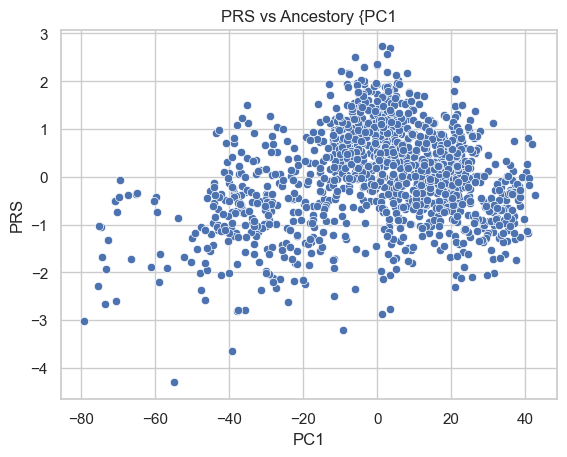

In [128]:
sns.scatterplot(x ="PC1",
                y = "PRS" ,
               data = PRS_df)
plt.title("PRS vs Ancestory {PC1}PRS vs Ancestory {PC1")
plt.show()

# Other Biologically Relevance plots and Visualizations...

In [130]:
print(HWE_filtered_df.shape)
print(genotype_df_HWE_filtered.shape)


(2742, 15)
(2504, 2742)


# Beta distribution of QC passed high confidence variants..

<function matplotlib.pyplot.show(close=None, block=None)>

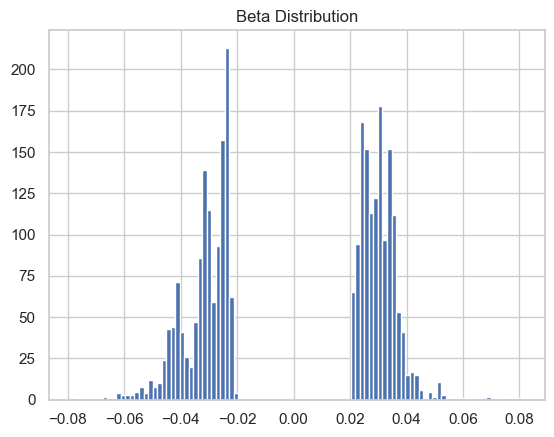

In [131]:
#BETA distribution..
plt.hist(HWE_filtered_df['BETA'] ,bins = 100)
plt.title("Beta Distribution" ,fontsize = 12)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

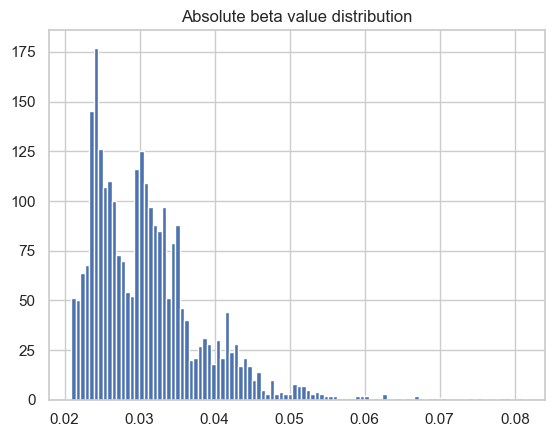

In [132]:
# Absolute beta value distribution..
plt.hist(abs(HWE_filtered_df['BETA']) ,bins = 100)
plt.title("Absolute beta value distribution" ,fontsize = 12)
plt.show

Removing low frequency Noice...

Duplicated variants check...

In [133]:
assert HWE_filtered_df['ID'].is_unique

array([[<Axes: title={'center': 'pos'}>,
        <Axes: title={'center': 'BETA'}>,
        <Axes: title={'center': 'NCAS'}>],
       [<Axes: title={'center': 'NCON'}>,
        <Axes: title={'center': 'PVAL'}>,
        <Axes: title={'center': 'FCAS'}>],
       [<Axes: title={'center': 'FCON'}>, <Axes: title={'center': 'AF'}>,
        <Axes: title={'center': 'MAF'}>],
       [<Axes: title={'center': 'mean_dosage'}>,
        <Axes: title={'center': 'mean_variance'}>, <Axes: >]],
      dtype=object)

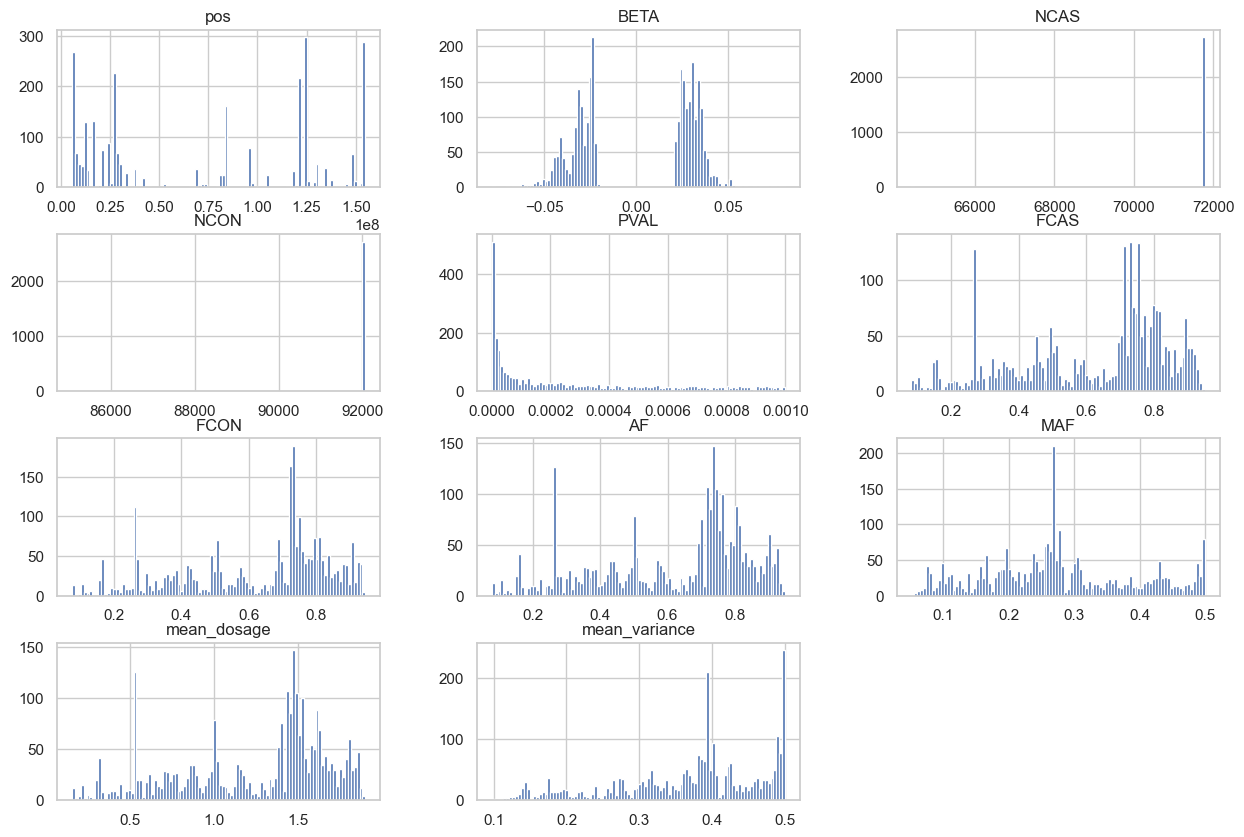

In [135]:
HWE_filtered_df.hist(bins=100, figsize=(15, 10))

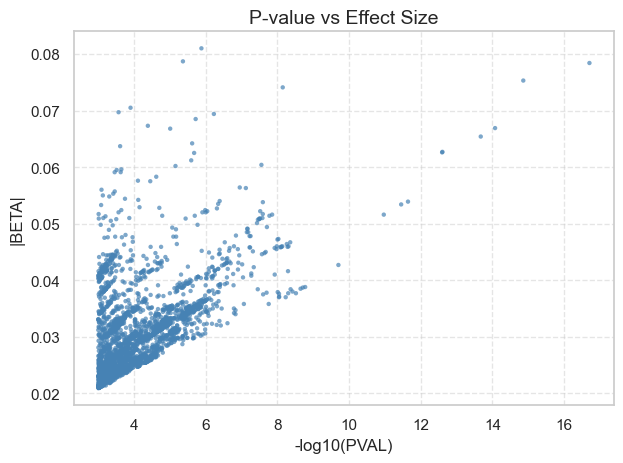

In [136]:
# P-value vs effect size relationship..
plt.scatter(
    -np.log10(HWE_filtered_df['PVAL']),      
    np.abs(HWE_filtered_df['BETA']),        
    s=10,                      
    alpha=0.7,                 
    c='steelblue',           
    edgecolor='none'           
)

# Add labels and style
plt.xlabel('-log10(PVAL)', fontsize=12)
plt.ylabel('|BETA|', fontsize=12)
plt.title('P-value vs Effect Size', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.5)  # light grid
plt.tight_layout()
plt.show()


In [ ]:
summary_study_df.hist(bins=100, figsize=(15, 10))

In [139]:
# High v/s low variance comparison...

# PRS Contribution per SNP
HWE_filtered_df['PRS_Contri'] = (HWE_filtered_df['mean_variance']*(df['BETA']**2) )


# Comparing high v/s low variance..
threshold = HWE_filtered_df['mean_variance'].median()   # or mean
HWE_filtered_df['variance_group'] = HWE_filtered_df['mean_variance'].apply(
    lambda v: 'High variance' if v >= threshold else 'Low variance'
)


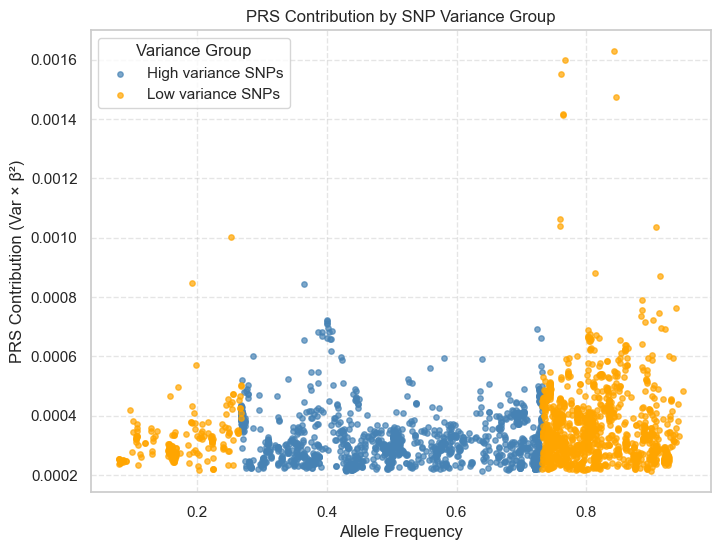

In [140]:
plt.figure(figsize=(8,6))

# Plot high variance SNPs
plt.scatter(HWE_filtered_df.loc[HWE_filtered_df['variance_group']=='High variance','AF'],
            HWE_filtered_df.loc[HWE_filtered_df['variance_group']=='High variance','PRS_Contri'],
            c='steelblue', s=15, alpha=0.7, label='High variance SNPs')

# Plot low variance SNPs
plt.scatter(HWE_filtered_df.loc[HWE_filtered_df['variance_group']=='Low variance','AF'],
            HWE_filtered_df.loc[HWE_filtered_df['variance_group']=='Low variance','PRS_Contri'],
            c='orange', s=15, alpha=0.7, label='Low variance SNPs')

# Axis labels and title
plt.xlabel('Allele Frequency')
plt.ylabel('PRS Contribution (Var × β²)')
plt.title('PRS Contribution by SNP Variance Group')

# Add legend
plt.legend(title='Variance Group')

# Grid for readability
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()


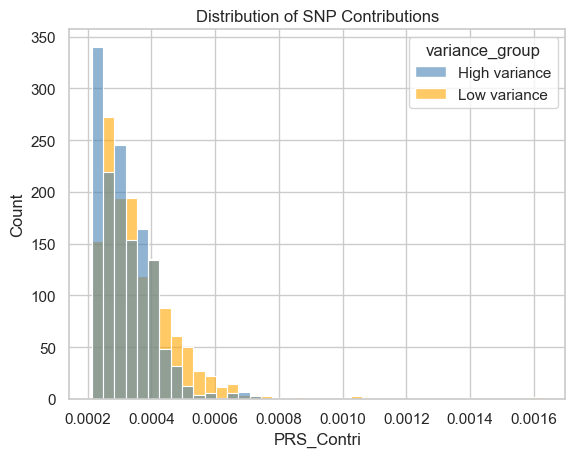

In [142]:
sns.histplot(data=HWE_filtered_df, x='PRS_Contri', hue='variance_group',
             bins=40, alpha=0.6, palette=['steelblue','orange'])
plt.title('Distribution of SNP Contributions')
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

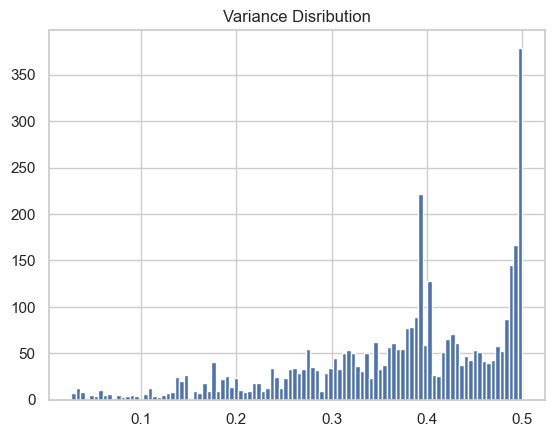

In [143]:
plt.hist(df['mean_variance'] ,bins = 100)
plt.title("Variance Disribution" ,fontsize= 12)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

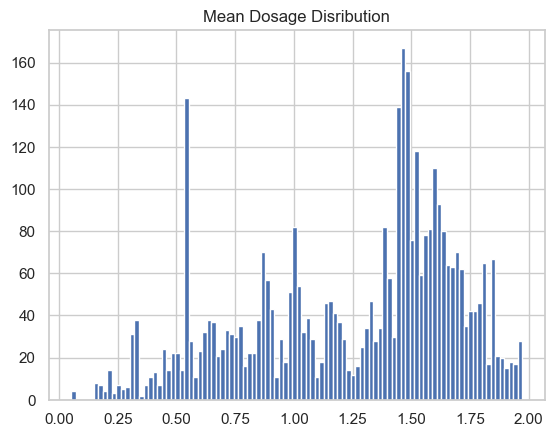

In [144]:
plt.hist(df['mean_dosage'] ,bins = 100)
plt.title("Mean Dosage Disribution" ,fontsize= 12)
plt.show